$ \textbf{Aluna:}$ Alessandra da Silva Dias Malizia   
$ \textbf{Professor:}$ Cristiano Fernandes   
$ \textbf{Data:}$ 17 de Abril e 8 de Maio de 2026

$ \textbf{Estudo Orientado - 2026.1:}$ Análise de quantis extremos de precipitação usando Gamma, GPD e transformação PIT

In [28]:
import numpy as np
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import statsmodels.api as sm
from matplotlib.ticker import PercentFormatter
import pandas as pd
from scipy.stats import norm, t, genpareto, genextreme, chi2, gamma, uniform, expon
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 
from arch import arch_model
import numdifftools as nd
from scipy.optimize import minimize
from naveau_model import NaveauModelI

In [2]:
rng = np.random.default_rng(seed=4)

In [3]:
path_img = r"C:\Users\aless\Documents\Mestrado\PUC\Tese\propostas\EO - chuvas"

# Dados
Dados baixados da base do Inmet pelo site https://basedosdados.org/dataset/782c5607-9f69-4e12-b0d5-aa0f1a7a94e2?table=28d16282-d100-4ea8-9dde-36c05c8f1ca2 em 04/04/2026

In [4]:
data = pd.read_csv(r"C:\Users\aless\Documents\Mestrado\PUC\Tese\propostas\dados de chuva quinzenal - porto alegre.csv").rename(columns={'quinzena': 'data', 'precipitacao_total': 'precipitacao'})
data['data'] = pd.to_datetime(data['data'])
series = data[['precipitacao','data']].set_index('data')['precipitacao']

data.head()

,id_estacao,estacao,data_fundacao,data,precipitacao
0,A801,Porto Alegre,2000-09-22,2000-10-04,102.0
1,A801,Porto Alegre,2000-09-22,2000-10-19,70.0
2,A801,Porto Alegre,2000-09-22,2000-11-03,26.8
3,A801,Porto Alegre,2000-09-22,2000-11-18,52.8
4,A801,Porto Alegre,2000-09-22,2000-12-03,76.6


In [5]:
series.sort_values().head(10)

data
2025-04-26    0.0
2021-04-17    0.2
2005-06-10    0.2
2013-12-25    0.2
2002-06-26    0.4
2009-05-05    0.4
2008-05-25    0.6
2003-08-20    0.6
2003-05-22    0.8
2020-10-19    1.0
Name: precipitacao, dtype: float64

In [6]:
series = series[series.index < pd.to_datetime('2025-04-26')]
pd.DataFrame(index=['Metadados'], data={
    'Série':'Precipitação quinzenal em Porto Alegre (mm)', 
    'Fonte': 'Inmet',
    'Período da série': '{} a {}'.format(series.index[0].strftime('%d/%m/%Y'), series.index[-1].strftime('%d/%m/%Y')),
    'Observações': '{}'.format(series.shape[0])
}).T

,Metadados
Série,Precipitação quinzenal em Porto Alegre (mm)
Fonte,Inmet
Período da série,04/10/2000 a 11/04/2025
Observações,597


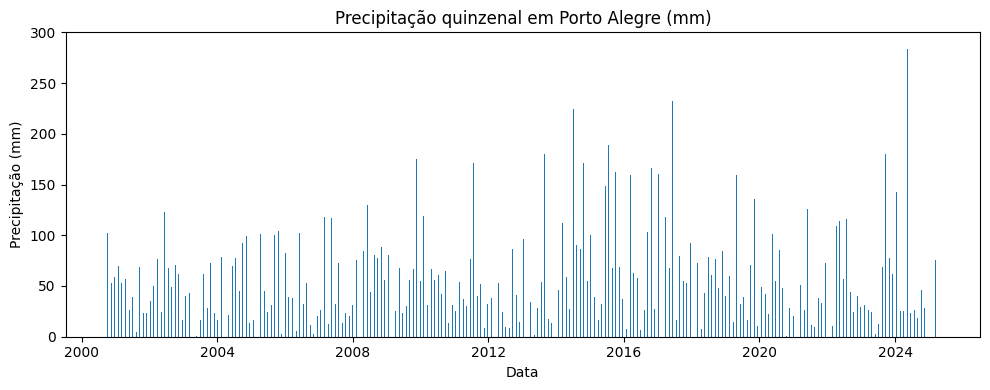

In [7]:
fig, ax = plt.subplots(figsize=(10,4))

ax.bar(series.index, series, width=4)
ax.set_title('Precipitação quinzenal em Porto Alegre (mm)')
ax.set_ylabel('Precipitação (mm)')
ax.set_xlabel('Data')
ax.set_ylim(top=300)
plt.tight_layout()
plt.show()

In [53]:
len(plot_data[0])

51

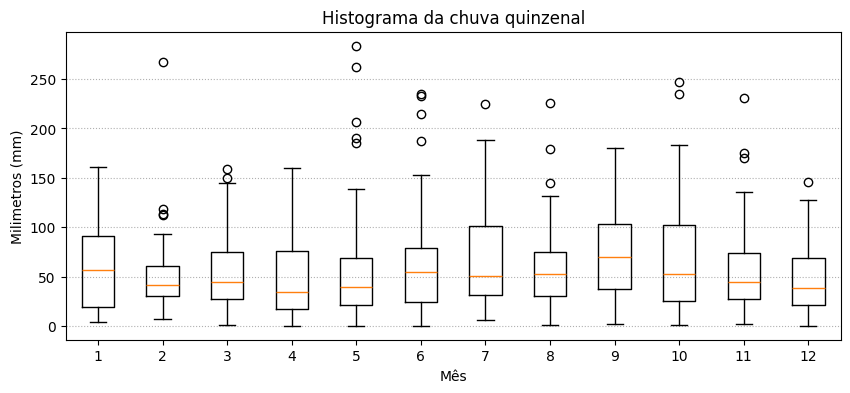

In [50]:
fig, ax = plt.subplots(figsize=(10,4))
plot_data = [
    series[series.index.month == m].values
    for m in range(1, 13)
]
ax.boxplot(plot_data)
ax.set_ylabel('Milimetros (mm)')
ax.set_xlabel('Mês')
ax.grid(axis='y', linestyle=':')
ax.set_title('Histograma da chuva quinzenal')
plt.show()

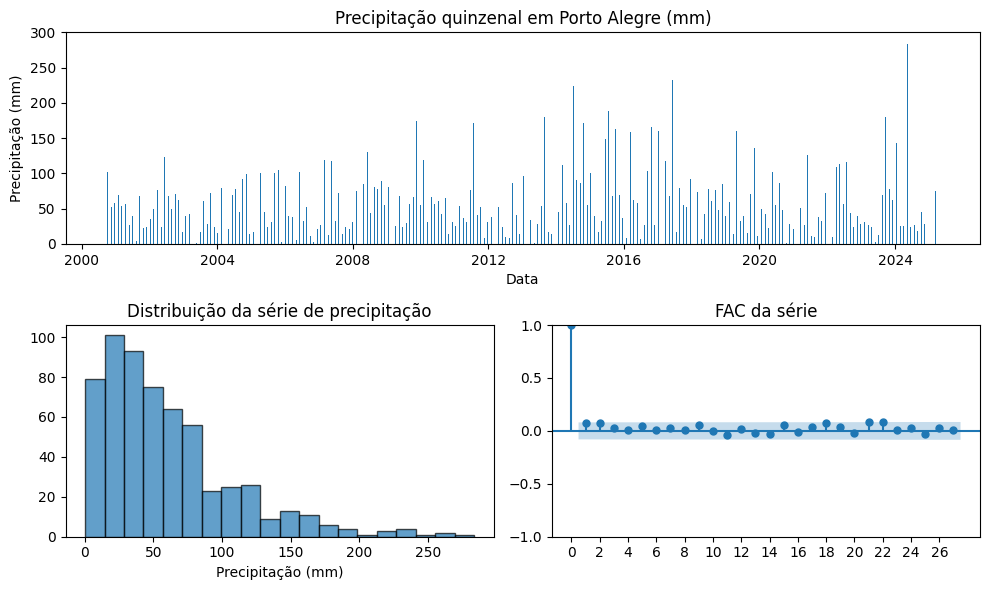

In [9]:
plot_count = 0

fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(2, 2)

ax0 = fig.add_subplot(gs[0, :])
ax0.bar(series.index, series, width=4)
ax0.set_title('Precipitação quinzenal em Porto Alegre (mm)')
ax0.set_ylabel('Precipitação (mm)')
ax0.set_xlabel('Data')
ax0.set_ylim(top=300)

ax1 = fig.add_subplot(gs[1, 0])
ax1.hist(series, bins=20, density=False, alpha=0.7, edgecolor='black')
ax1.set_title('Distribuição da série de precipitação')
ax1.set_xlabel('Precipitação (mm)')

ax2 = fig.add_subplot(gs[1, 1])
lags = 27
plot_acf(series, lags=lags, ax=ax2, title='FAC da série')
ax2.set_xticks(np.arange(0, lags+1, 2))
ax2.set_xticklabels(np.arange(0, lags+1, 2))

fig.tight_layout()
plot_count += 1
plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

In [10]:
acf_vals = acf(series, nlags=30, fft=True)
acf_vals[25:]

array([-0.03318271,  0.02626172,  0.00819704,  0.02604884,  0.0551507 ,
        0.04374332])

# Modelagem

## Gamma
$$
y_t \sim \text{Gamma}(\alpha, \theta) \\
$$

In [11]:
gamma_params = gamma.fit(series, floc=0)
alpha_hat, loc_hat, theta_hat = gamma_params

x = np.linspace(series.min(), series.max(), 100)
pit = gamma.cdf(series, alpha_hat, loc=loc_hat, scale=theta_hat)

print(f"Parâmetros estimados da Gamma:\nalpha={alpha_hat:.2f}, loc={loc_hat:.2f}, theta={theta_hat:.2f}")

df_quantiles = pd.DataFrame(index=['Gamma','GPD', 'GPD + Gamma','GPD + Pit'],
                           columns = ['95.0%','99.0%','99.9%'])
for alpha in [0.95, 0.99, 0.999]:
    df_quantiles.loc['Gamma', f'{(alpha*100)}%'] = gamma.ppf(alpha, alpha_hat, loc=loc_hat, scale=theta_hat)

Parâmetros estimados da Gamma:
alpha=1.36, loc=0.00, theta=44.33


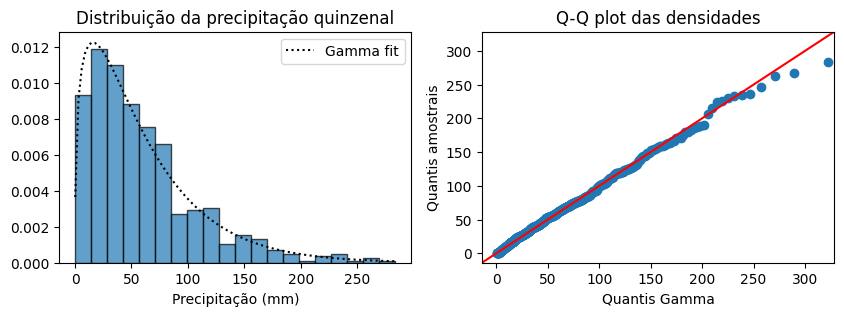

In [12]:
fig, ax = plt.subplots(1,2, figsize=(10, 3))

ax[0].plot(x, gamma.pdf(x, alpha_hat, loc=loc_hat, scale=theta_hat), 'k', linestyle=':', label='Gamma fit')
ax[0].hist(series, bins=20, density=True, alpha=0.7, edgecolor='black')
ax[0].set_title('Distribuição da precipitação quinzenal')
ax[0].set_xlabel('Precipitação (mm)')
ax[0].legend()

ax[1].set_title(f'Q-Q plot das densidades')
sm.qqplot(series, ax=ax[1], line='45', dist=gamma, distargs=(alpha_hat,), loc=loc_hat, scale=theta_hat)
ax[1].set_xlabel('Quantis Gamma')
ax[1].set_ylabel('Quantis amostrais')

plot_count+=1
plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

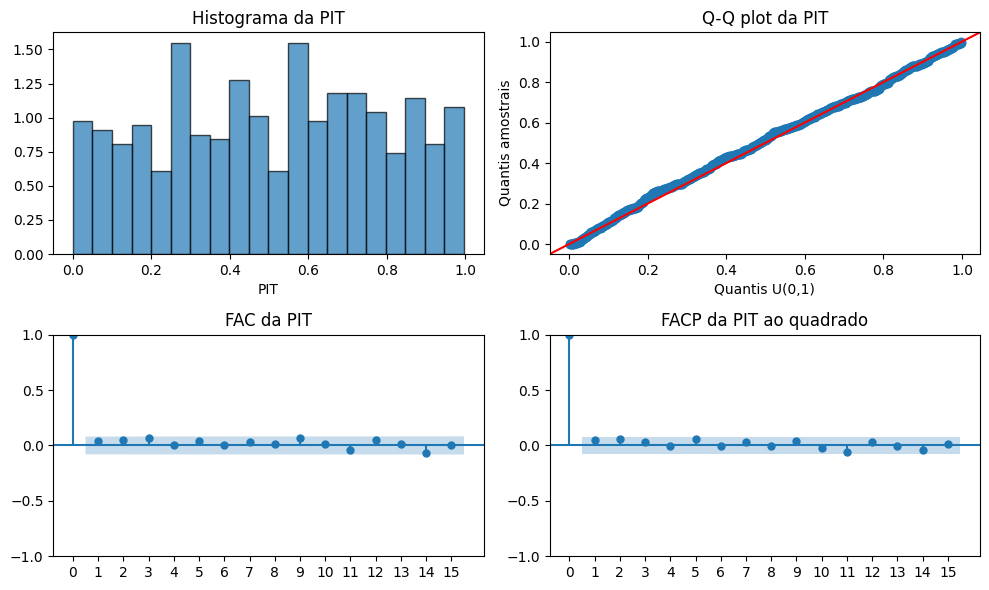

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(10, 6))

# linha 1
ax[0,0].hist(pit, bins=20, density=True, edgecolor='black', alpha=0.7)
ax[0,0].set_title('Histograma da PIT')
ax[0,0].set_xlabel('PIT')

ax[0,1].set_title('Q-Q plot da PIT')
sm.qqplot(pit, dist=uniform, line='45', ax=ax[0,1], loc=0, scale=1)
ax[0,1].set_xlabel('Quantis U(0,1)')
ax[0,1].set_ylabel('Quantis amostrais')

# linha 2
lags = 15

plot_acf(pit, lags=lags, ax=ax[1,0], title='FAC da PIT')
ax[1,0].set_xticks(np.arange(lags+1))
ax[1,0].set_xticklabels(np.arange(lags+1))

plot_pacf(pit**2, lags=lags, ax=ax[1,1], title='FACP da PIT ao quadrado')
ax[1,1].set_xticks(np.arange(lags+1))
ax[1,1].set_xticklabels(np.arange(lags+1))

fig.tight_layout()

plot_count += 1
plt.savefig(path_img + r"\plot{}.png".format(plot_count))

plt.show()

In [14]:
# fig, ax = plt.subplots(1,2, figsize=(10, 3))

# ax[0].hist(pit, bins=20, density=True, edgecolor='black', alpha=0.7)
# ax[0].set_title('Histograma da PIT')
# ax[0].set_xlabel('PIT')

# ax[1].set_title(f'Q-Q plot da PIT')
# sm.qqplot(pit, dist=uniform, line='45', ax=ax[1], loc=0, scale=1)
# ax[1].set_xlabel('Quantis U(0,1)')
# ax[1].set_ylabel('Quantis amostrais')

# plot_count+=1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
# plt.show()

In [15]:
# fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# lags=15
# plot_acf(pit,lags=lags, ax=ax[0], title=f'FAC da pit')
# ax[0].set_xticks(np.arange(lags+1))
# ax[0].set_xticklabels(np.arange(lags+1))

# plot_pacf(pit**(2),lags=lags, ax=ax[1], title=f'FACP da pit ao quadrado')
# ax[1].set_xticks(np.arange(lags+1))
# ax[1].set_xticklabels(np.arange(lags+1))

# fig.tight_layout()
# plot_count+=1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
# plt.show()

## GPD

$$
\begin{aligned}
y_t &\sim \text{GPD}(\xi, \beta) \\   
q_{alpha} &= u + \frac{\beta}{\xi} \left( \left( \frac{1 - \alpha}{p_u} \right)^{-\xi} - 1 \right), \quad \text{onde} \quad p_u = P(Y > u)
\end{aligned}
$$

In [14]:
thresholds = np.arange(0.75, 0.95, 0.01)
threshold_values = np.quantile(series, thresholds)
obs_below = [(series > t).sum() for t in threshold_values]
df_thresholds = pd.DataFrame({
    'Threshold (%)': thresholds * 100,
    'Threshold value (mm)': threshold_values,
    'Obs above': obs_below
})
df_thresholds

    Threshold (%)  Threshold value (mm)  Obs above
0            75.0                79.000        149
1            76.0                81.192        144
2            77.0                83.784        138
3            78.0                84.400        131
4            79.0                88.112        126
5            80.0                91.440        120
6            81.0                92.752        114
7            82.0                98.088        108
8            83.0               101.208        102
9            84.0               103.256         96
10           85.0               107.680         90
11           86.0               111.760         84
12           87.0               116.536         78
13           88.0               118.696         72
14           89.0               121.064         66
15           90.0               124.640         60
16           91.0               128.632         54
17           92.0               138.128         48
18           93.0              

In [15]:
# cálculo dos excessos
alpha_t = 0.83
threshold = np.quantile(series, alpha_t)
exceedances = series[series > threshold] - threshold

print(f"{alpha_t:.0%} threshold: {threshold:.2f}mm")
print(f'Quantidade de observações extremas: {exceedances.shape[0]}')

# estimação do modelo por ML
xi, loc, beta = genpareto.fit(exceedances, floc=0)
y_gpd = genpareto.pdf((x[x > threshold] - threshold), xi, loc=loc, scale=beta)
print('\nParâmetros estimados da GPD: \nxi={:.2f} \nloc={:.4f} \nscale={:.4f}'.format(xi, loc, beta))

# cálculo do quantil    
for alpha in [0.95, 0.99, 0.999]:
    # GPD pura com p_u empírico
    p_u = len(exceedances) / len(series)
    q = threshold + (beta/xi) * (((1-alpha) / p_u)**(-xi) - 1)
    df_quantiles.loc['GPD', f'{(alpha*100)}%'] = q
    
    # GPD com Gamma
    p_u = 1 - gamma.cdf(threshold, alpha_hat, loc=loc_hat, scale=theta_hat)
    q = threshold + (beta/xi) * (((1-alpha) / p_u)**(-xi) - 1)
    # df_quantiles.loc['GPD + Gamma', f'{(alpha*100)}%'] = q
    

83% threshold: 101.21mm
Quantidade de observações extremas: 102

Parâmetros estimados da GPD: 
xi=-0.14 
loc=0.0000 
scale=52.5393


### Testes de confiança

In [16]:
def likelihood_ratio_test(exceedances, xi, beta):
    """
    Likelihood Ratio Test: H0: xi=0 (Exponential), H1: xi=xi_hat (GPD)'
    
    Se p_value < 0.05, o teste rejeita H0 (xi=0): há evidências de que a cauda segue uma GPD (xi ≠ 0), ou seja, a cauda é mais pesada que a exponencial
    Se não, o teste não rejeita H0 (xi=0): não há evidências suficientes para rejeitar a hipótese de cauda exponencial (xi ≈ 0).
    
    Returns:
        LR: float
            Likelihood ratio statistic.
        p_value: float
            p-value for the test (significance of xi ≠ 0).
    """
    # Log-likelihood for GPD (xi estimated)
    ll_gpd = genpareto.logpdf(exceedances, xi, loc=0, scale=beta).sum()

    # Log-likelihood for Exponential (xi=0)
    beta0 = exceedances.mean()  # MLE for exponential scale
    ll_exp = expon.logpdf(exceedances, loc=0, scale=beta0).sum() # For xi=0, GPD reduces to Exponential with scale=beta0

    LR = 2 * (ll_gpd - ll_exp) # Likelihood ratio statistic
    p_value = 1 - chi2.cdf(LR, df=1)
    return LR, p_value

In [17]:
# likelihood ratio test nos parâmetros estimados
LR, p_value = likelihood_ratio_test(exceedances, xi, beta)

print(f"Likelihood Ratio statistic: {LR:.2f}")
print(f"P-value: {p_value:.4f}")

Likelihood Ratio statistic: 1.46
P-value: 0.2272


In [18]:
# Cálculo do intervalo de confiança com profile likelihood
xis = np.linspace(-0.4, 0.2, 100)
LR_vals = []

ll_max = genpareto.logpdf(exceedances, xi, loc=0, scale=beta).sum()
for temp_xi in xis:
    temp_beta = genpareto.fit(exceedances, floc=0, fc=temp_xi)[2]
    ll = genpareto.logpdf(exceedances, temp_xi, loc=0, scale=temp_beta).sum()
    temp_LR = 2 * (ll_max - ll)
    LR_vals.append(temp_LR)

# IC 95% para xi: valores de xi onde LR <= 3.84 (chi2 com 1 grau de liberdade)
xi_ci = xis[np.array(LR_vals) <= 3.84]
xi_ci_min, xi_ci_max = xi_ci.min(), xi_ci.max()

print(f"IC 95% para xi por PL: [{xi_ci_min:.2f}, {xi_ci_max:.2f}]")
print('xi com máxima verossimilhança por profile likelihood: {:.3f}'.format(xis[np.array(LR_vals) == np.min(LR_vals)][0]))

IC 95% para xi por PL: [-0.15, 0.10]
xi com máxima verossimilhança por profile likelihood: -0.145


In [19]:
# cálculo da matriz de covariância dos parâmetros numericamente por hessiana da log-verossimilhança
def loglik(params, data):
    xi, beta = params
    if beta <= 0:
        return -np.inf
    return genpareto.logpdf(data, c=xi, loc=0, scale=beta).sum()
    
hessian = nd.Hessian(lambda p: loglik(p, exceedances))(np.array([xi, beta]))
cov_matrix = -np.linalg.inv(hessian)
se_xi = np.sqrt(cov_matrix[0, 0])

ci_lower, ci_upper = xi - 1.96 * se_xi, xi + 1.96 * se_xi
print(f"Desvio padrão do xi: {se_xi:.2f}")
print(f"IC 95% para xi por ML: [{ci_lower:.2f}, {ci_upper:.2f}]")

Desvio padrão do xi: 0.11
IC 95% para xi por ML: [-0.35, 0.07]


In [20]:
# Estimações para cada threshold

xis, statistics, p_values = [], [], []
thresholds = np.arange(0.75, 0.91, 0.01)
for alpha_t in thresholds:
    temp_threshold = np.quantile(series, alpha_t)
    temp_exceedances = series[series > temp_threshold] - temp_threshold
    temp_xi, temp_loc, temp_beta = genpareto.fit(temp_exceedances, floc=0)
    xis.append(temp_xi)

    LR, p_value = likelihood_ratio_test(temp_exceedances, temp_xi, temp_beta)
    statistics.append(LR)
    p_values.append(p_value)   
xis = np.array(xis)

df_thresholds.loc[df_thresholds['Threshold (%)'].isin(thresholds*100), 'Xi'] = xis
df_thresholds.loc[df_thresholds['Threshold (%)'].isin(thresholds*100), 'Statistic'] = statistics
df_thresholds.loc[df_thresholds['Threshold (%)'].isin(thresholds*100), 'p-value'] = p_values
df_thresholds.round(2)

,Threshold (%),Threshold value (mm),Obs above,Xi,Statistic,p-value
0,75.0,79.00,149,-0.16,3.03,0.08
1,76.0,81.19,144,-0.16,2.71,0.10
2,77.0,83.78,138,-0.15,2.42,0.12
3,78.0,84.40,131,-0.20,4.21,0.04
4,79.0,88.11,126,-0.17,2.93,0.09
5,80.0,91.44,120,-0.16,2.36,0.12
6,81.0,92.75,114,-0.19,3.38,0.07
7,82.0,98.09,108,-0.15,1.65,0.20
8,83.0,101.21,102,-0.14,1.46,0.23
9,84.0,103.26,96,-0.17,2.03,0.15


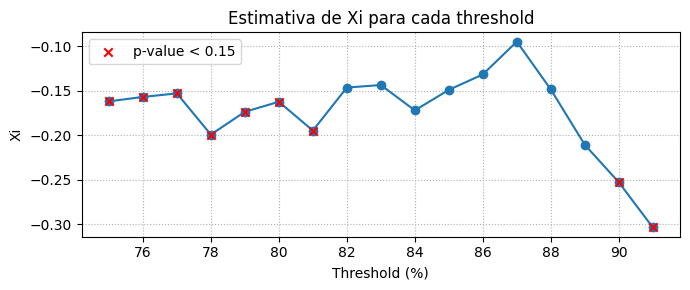

In [21]:
pvalue_alpha = 0.15
red_points = df_thresholds['p-value'] < pvalue_alpha

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(df_thresholds['Threshold (%)'], df_thresholds['Xi'], marker='o', color='C0')
ax.scatter(df_thresholds['Threshold (%)'][red_points], df_thresholds['Xi'][red_points], color='red', zorder=5, label=f'p-value < {pvalue_alpha}', marker='x')
ax.set_xlabel('Threshold (%)')
ax.set_ylabel('Xi')
ax.legend()
ax.set_title('Estimativa de Xi para cada threshold')
ax.grid(True, linestyle=':')
plt.tight_layout()
# plot_count += 1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

### Plots

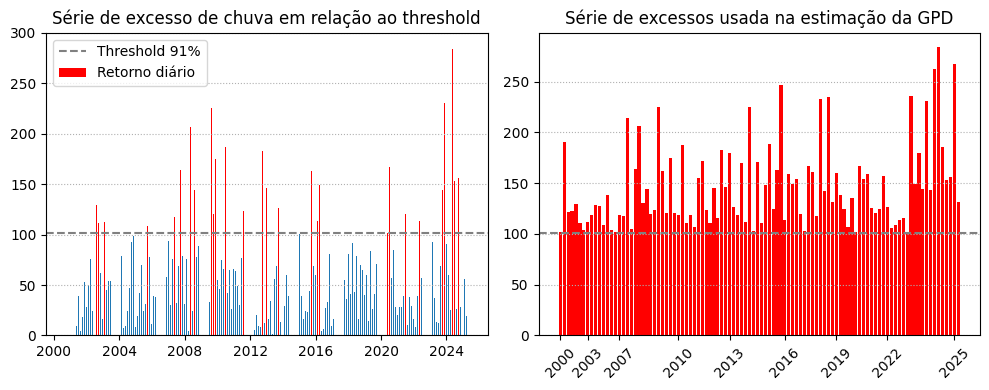

In [22]:
fig, ax = plt.subplots(1,2,figsize=(10,4))

bar_colors = ['red' if v > threshold else 'C0' for v in series]
ax[0].bar(series.index, series, width=6, color=bar_colors, label='Retorno diário')
ax[0].axhline(threshold, color='gray', linestyle='--', label='Threshold {:.0%}'.format(alpha_t))
ax[0].set_ylim(top=300)
ax[0].grid(axis='y', linestyle=':')
ax[0].legend()
ax[0].set_title('Série de excesso de chuva em relação ao threshold')

ticks, labels = [], []
years = exceedances.sort_index().index.year
unique_years = sorted(years.unique())
for y in unique_years[::3]:
    idx = np.where(years == y)[0][0]
    ticks.append(idx)
    labels.append(str(y))
        
ax[1].bar(np.arange(len(exceedances)), series[series > threshold].sort_index(), color='red', label='Excessos')
ax[1].set_xticks(ticks)
ax[1].set_xticklabels(labels, rotation=45)
ax[1].axhline(threshold, color='gray', linestyle='--', label=f'Threshold {alpha_t:.0%}')
ax[1].grid(axis='y', linestyle=':')
ax[1].set_title('Série de excessos usada na estimação da GPD')

fig.tight_layout()
plot_count+=1
plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

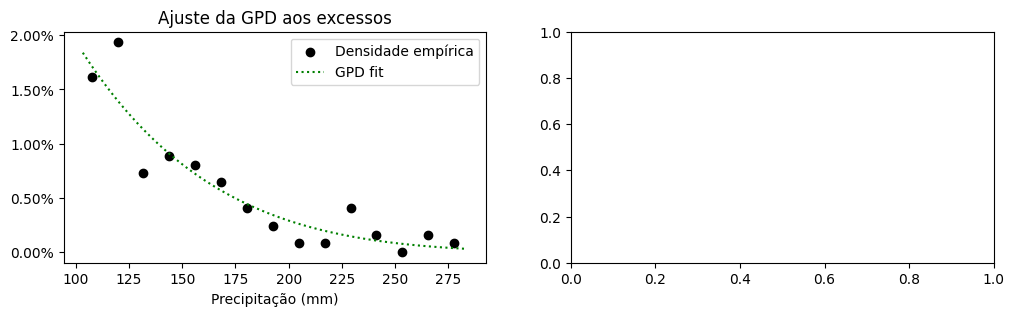

In [23]:
fig, ax = plt.subplots(1,2,figsize=(12,3))

hist, bin_edges = np.histogram(series[series > threshold], bins=15, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
ax[0].scatter(bin_centers, hist, color='black', label='Densidade empírica')
ax[0].plot(x[x > threshold], y_gpd, 'g', linestyle=':', label='GPD fit')
ax[0].yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=2))
ax[0].set_title('Ajuste da GPD aos excessos')
ax[0].set_xlabel('Precipitação (mm)')
ax[0].legend()

# hist, bin_edges = np.histogram(monthly_min, bins=15, density=True)
# bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# ax[1].scatter(bin_centers, hist, color='black', label='Densidade empírica')
# ax[1].plot(x[y_gev > 0], y_gev[y_gev > 0], 'b', linestyle=':', label='GEV fit')
# ax[1].xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
# ax[1].set_title('AAPL | Ajuste GEV aos mínimos mensais')
# ax[1].set_xlabel('Retorno (%)')
# ax[1].legend()

plt.show()

## GPD na Pit

In [24]:
u = 0.85
pit_exceedances = pit[pit > u] - u
print(f'Quantidade de observações extremas: {pit_exceedances.shape[0]}')

xi, loc, beta = genpareto.fit(pit_exceedances, floc=0)
# y_gpd = genpareto.pdf((x[x > threshold] - threshold), xi, loc=loc, scale=beta)
print('\nParâmetros estimados da GPD na pit: \nxi={:.2f} \nloc={:.4f} \nscale={:.4f}'.format(xi, loc, beta))

# cálculo do quantil    
for alpha in [0.95, 0.99, 0.999]:
    # quantil da GPD sobre a pit
    p_u = len(pit_exceedances) / len(pit)
    q_u = u + (beta/xi) * (((1-alpha) / p_u)**(-xi) - 1)
    # quantil da série usando a pit como entrada para a gamma inversa
    q = gamma.ppf(q_u, a=alpha_hat, loc=loc_hat, scale=theta_hat)
    df_quantiles.loc['GPD + Pit', f'{(alpha*100)}%'] = q 

Quantidade de observações extremas: 89

Parâmetros estimados da GPD na pit: 
xi=-1.07 
loc=0.0000 
scale=0.1568


## Naveau Model I
$$
\begin{aligned}
y_t &\sim G\left\{
H_\xi\left(\dfrac{x}{\sigma}\right)
\right\}, \qquad \sigma>0\\
G(v)
&=
v^\kappa,
\qquad
\kappa>0
\end{aligned}
$$

In [29]:
def negloglik(params, data):

    kappa, sigma, xi = params
    if kappa <= 0 or sigma <= 0: # restrições
        return np.inf

    model = NaveauModelI(kappa, sigma, xi)
    logf = model.logpdf(data)

    if np.any(~np.isfinite(logf)):
        return np.inf

    return -np.sum(logf)

In [34]:
init = [1.0, 1.0, 0.1]

res = minimize(
    negloglik,
    x0=init,
    args=(series,),
    method="L-BFGS-B",
    bounds=[
        (1e-6, None),   # kappa
        (1e-6, None),   # sigma
        (-1, 5)         # xi
    ]
)
print("-------------------------------------------------------")
print("Parâmetros estimados do naveau m1: \nkappa={:.2f}, \nsigma={:.2f}, \nxi={:.2f}".format(*res.x))
print("-------------------------------------------------------\n")
res

-------------------------------------------------------
Estimated params: kappa=1.25, sigma=57.86, xi=-0.10
-------------------------------------------------------



  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 3025.611478539708
        x: [ 1.254e+00  5.786e+01 -1.024e-01]
      nit: 24
      jac: [-9.095e-05  1.364e-04  5.139e-03]
     nfev: 112
     njev: 28
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [40]:
kappa_hat, sigma_hat, xi_hat = res.x
model_fit = NaveauModelI(kappa_hat, sigma_hat, xi_hat)

x = np.linspace(series.min(), series.max(), 100)
pit = model_fit.cdf(series)

for alpha in [0.95, 0.99, 0.999]:
    df_quantiles.loc['Naveau', f'{(alpha*100)}%'] = model_fit.ppf(alpha)

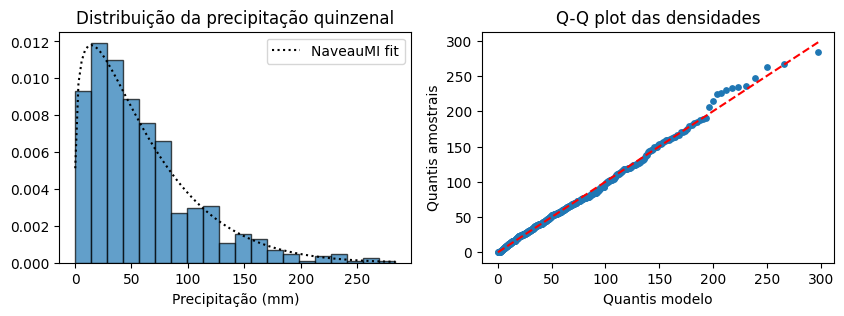

In [45]:
fig, ax = plt.subplots(1,2, figsize=(10, 3))

ax[0].plot(x, model_fit.pdf(x), 'k', linestyle=':', label='NaveauMI fit')
ax[0].hist(series, bins=20, density=True, alpha=0.7, edgecolor='black')
ax[0].set_title('Distribuição da precipitação quinzenal')
ax[0].set_xlabel('Precipitação (mm)')
ax[0].legend()

# probabilidades teóricas
p = (np.arange(1, len(series) + 1) - 0.5) / len(series)
theoretical_q, sample_q = model_fit.ppf(p), np.sort(series)
ax[1].scatter(theoretical_q, sample_q, s=15)
# linha 45 graus
min_q = min(theoretical_q.min(), sample_q.min())
max_q = max(theoretical_q.max(), sample_q.max())
ax[1].plot([min_q, max_q], [min_q, max_q], 'r--')
ax[1].set_title(f'Q-Q plot das densidades')
ax[1].set_xlabel('Quantis modelo')
ax[1].set_ylabel('Quantis amostrais')

# plot_count+=1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

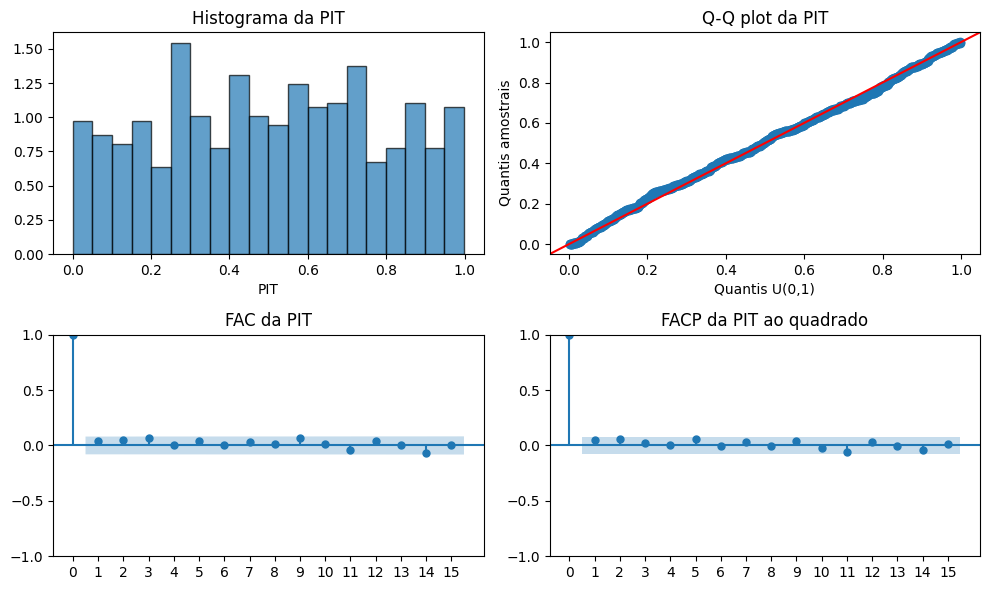

In [46]:
fig, ax = plt.subplots(2, 2, figsize=(10, 6))

# linha 1
ax[0,0].hist(pit, bins=20, density=True, edgecolor='black', alpha=0.7)
ax[0,0].set_title('Histograma da PIT')
ax[0,0].set_xlabel('PIT')

ax[0,1].set_title('Q-Q plot da PIT')
sm.qqplot(pit, dist=uniform, line='45', ax=ax[0,1], loc=0, scale=1)
ax[0,1].set_xlabel('Quantis U(0,1)')
ax[0,1].set_ylabel('Quantis amostrais')

# linha 2
lags = 15

plot_acf(pit, lags=lags, ax=ax[1,0], title='FAC da PIT')
ax[1,0].set_xticks(np.arange(lags+1))
ax[1,0].set_xticklabels(np.arange(lags+1))

plot_pacf(pit**2, lags=lags, ax=ax[1,1], title='FACP da PIT ao quadrado')
ax[1,1].set_xticks(np.arange(lags+1))
ax[1,1].set_xticklabels(np.arange(lags+1))

fig.tight_layout()
# plot_count += 1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

# Resultados

In [47]:
df_quantiles.astype(float).round(2)

,95.0%,99.0%,99.9%
Gamma,162.11,238.54,345.76
GPD,160.40,223.71,292.29
GPD + Gamma,NaN,NaN,NaN
GPD + Pit,162.98,230.49,276.10
Naveau,158.57,220.47,292.86


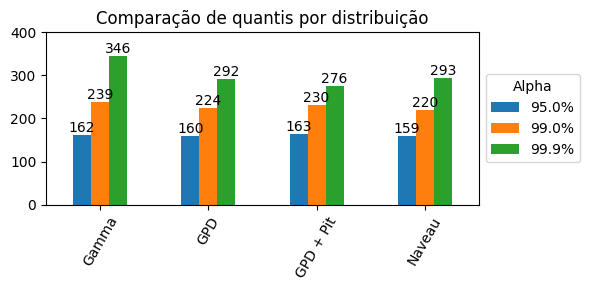

In [48]:
ax = df_quantiles.dropna().plot(kind="bar", figsize=(6,3))

ax.set_title("Comparação de quantis por distribuição")
ax.set_ylim(0,400)
# ax.invert_yaxis()
# ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.legend(title="Alpha",
          loc='center left',
          bbox_to_anchor=(1, 0.5))
for label in ax.get_xticklabels():
    label.set_rotation(60)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f",
                 labels=[f"{v:.0f}" for v in container.datavalues])
plt.tight_layout()
plot_count+=1
plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()